In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Extracting the data
def load_data(path):
    df=pd.read_csv(path)
    return df
df=load_data("data/Mobiles_Dataset.csv")
cols=["Product Name","Actual price","Discount price","Stars","Rating","Reviews"]
df_clean=df[cols].copy()
df_clean.head()

,Product Name,Actual price,Discount price,Stars,Rating,Reviews
0,"Apple iPhone 15 (Green, 128 GB)","₹79,600","₹65,999",4.6,"44,793 Ratings","2,402 Reviews"
1,"Apple iPhone 15 (Blue, 128 GB)","₹79,600","₹65,999",4.6,"44,793 Ratings","2,402 Reviews"
2,"Apple iPhone 15 (Black, 128 GB)","₹79,600","₹65,999",4.6,"44,793 Ratings","2,402 Reviews"
3,"OnePlus N20 SE (JADE WAVE, 128 GB)","₹19,999","₹11,489",4.0,"1,005 Ratings",41 Reviews
4,"OnePlus N20 SE (BLUE OASIS, 64 GB)","₹16,999","₹12,999",4.0,"1,005 Ratings",41 Reviews


In [3]:
#Data Preprocessing
def clean_data(df):
    df=df.copy()
    #Actual price and Discount price
    price_cols = ["Actual price", "Discount price"]
    for col in price_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("₹", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip()
            .replace(["NIL", "nil", "", " "], np.nan)
        )

        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    #Ratings
    df["Rating"]=(
    df["Rating"]
    .str.replace("Ratings","",regex=False)
    .str.replace(",","",regex=False)
    .str.strip()
    .replace(["NIL", "nil", ""], np.nan)
    )
    df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
    #Reviews
    df["Reviews"]=(
    df["Reviews"]
    .str.replace("Reviews","",regex=False)
    .str.replace(",","",regex=False)
    .str.strip()
    .replace(["NIL", "nil", ""], np.nan)
    )
    df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
    #Renaming column
    df.rename(columns={"Actual price":"Actual_price","Discount price":"Discount_price"},inplace=True)
    return df
    
clean_df=clean_data(df_clean)
clean_df.isna().sum()

Product Name       0
Actual_price      54
Discount_price     4
Stars              0
Rating             0
Reviews            0
dtype: int64

In [4]:
#Dropping invalid rows
def drop_nan(df):
    df=df.copy()
    df=df.dropna(subset=["Product Name","Actual_price"])
    return df
clean_df=drop_nan(clean_df)
clean_df.head()

,Product Name,Actual_price,Discount_price,Stars,Rating,Reviews
0,"Apple iPhone 15 (Green, 128 GB)",79600.0,65999.0,4.6,44793,2402
1,"Apple iPhone 15 (Blue, 128 GB)",79600.0,65999.0,4.6,44793,2402
2,"Apple iPhone 15 (Black, 128 GB)",79600.0,65999.0,4.6,44793,2402
3,"OnePlus N20 SE (JADE WAVE, 128 GB)",19999.0,11489.0,4.0,1005,41
4,"OnePlus N20 SE (BLUE OASIS, 64 GB)",16999.0,12999.0,4.0,1005,41


In [5]:
#Discount percentage %
def discount_percentage(df):
    df=df.copy()
    valid_row=(
        df["Actual_price"].notna() &
        df["Discount_price"].notna() &
        df["Actual_price"] > 0
    )
    df.loc[valid_row,"discount_percentage"]=(
        100-((df.loc[valid_row,"Discount_price"]*100)/df.loc[valid_row,"Actual_price"])
    ).round(2)
    return df
clean_df=discount_percentage(clean_df)

In [6]:
#Brand column
def add_brand(df):
    df=df.copy()
    df["brand"]=df["Product Name"].str.split(" ").str[0]
    df["brand"]=df["brand"].replace("SAMSUNG","Samsung")
    df["brand"]=df["brand"].replace("MOTOROLA","Motorola")
    return df
clean_df=add_brand(clean_df)
clean_df

,Product Name,Actual_price,Discount_price,Stars,Rating,Reviews,discount_percentage,brand
0,"Apple iPhone 15 (Green, 128 GB)",79600.0,65999.0,4.6,44793,2402,17.09,Apple
1,"Apple iPhone 15 (Blue, 128 GB)",79600.0,65999.0,4.6,44793,2402,17.09,Apple
2,"Apple iPhone 15 (Black, 128 GB)",79600.0,65999.0,4.6,44793,2402,17.09,Apple
3,"OnePlus N20 SE (JADE WAVE, 128 GB)",19999.0,11489.0,4.0,1005,41,42.55,OnePlus
4,"OnePlus N20 SE (BLUE OASIS, 64 GB)",16999.0,12999.0,4.0,1005,41,23.53,OnePlus
...,...,...,...,...,...,...,...,...
979,Kechaoda A27,1499.0,967.0,4.0,11022,693,35.49,Kechaoda
980,Kechaoda A27,1499.0,975.0,4.0,11022,693,34.96,Kechaoda
981,Kechaoda A27,1499.0,975.0,4.0,11022,693,34.96,Kechaoda
982,Kechaoda A27,1499.0,930.0,4.0,11022,693,37.96,Kechaoda


In [7]:
#Average Stars and rating
def brand_rating_summary(df):
    df1=df.copy()
    df1=df1.groupby("brand").agg(
        avg_stars=("Stars","mean"),
        rating_sum=("Rating","sum")
    )
    return df1
rated_brand=brand_rating_summary(clean_df)
rated_brand.sort_values("avg_stars",ascending=False)

,avg_stars,rating_sum
brand,,
Apple,4.600000,5689393
OnePlus,4.408333,722204
Nothing,4.400000,290150
vivo,4.389610,3252760
CMF,4.350000,31236
Xiaomi,4.350000,3028
OPPO,4.343478,106647
IQOO,4.340000,31938
realme,4.291870,1246877


In [8]:
#Brand Offering high ratings at lower price
def best_value_products(df):
    df1=df.copy()
    df1=df1.query("Stars>4 & Reviews>200").sort_values("Actual_price").head(10)
    return df1
value_deals=best_value_products(clean_df)
value_deals

,Product Name,Actual_price,Discount_price,Stars,Rating,Reviews,discount_percentage,brand
974,LAVA A3 vibe,1319.0,1212.0,4.2,21425,2247,8.11,LAVA
977,Kechaoda K115,1350.0,1069.0,4.1,35912,2497,20.81,Kechaoda
225,LAVA A3 Vibe,1399.0,1199.0,4.2,29747,2911,14.30,LAVA
106,Kechaoda K115,1499.0,1060.0,4.1,35912,2497,29.29,Kechaoda
358,Nokia 105 DS,1499.0,1099.0,4.1,18659,1818,26.68,Nokia
323,Kechaoda K115,1499.0,1060.0,4.1,35912,2497,29.29,Kechaoda
676,"Nokia 105 Single SIM, Keypad Mobile Phone with...",1595.0,1299.0,4.1,107686,6681,18.56,Nokia
675,"Nokia 105 Single SIM, Keypad Mobile Phone with...",1595.0,1299.0,4.1,107686,6681,18.56,Nokia
623,"Nokia 105 Single SIM, Keypad Mobile Phone with...",1596.0,1299.0,4.1,107686,6681,18.61,Nokia
808,"Nokia 105 Single SIM, Keypad Mobile Phone with...",1597.0,1299.0,4.1,107686,6681,18.66,Nokia


In [9]:
#Do higher discounts actually lead to better user satisfaction
def user_satisfaction_with_discounts(df):
    df1=df.copy()
    df1=df1.sort_values("discount_percentage",ascending=False).head(10)
    return df1
user_satisfaction=user_satisfaction_with_discounts(clean_df)
user_satisfaction

,Product Name,Actual_price,Discount_price,Stars,Rating,Reviews,discount_percentage,brand
204,I Kall K29-Pro 4G Phone,2599.0,1169.0,3.7,381,27,55.02,I
532,Vox V16,1649.0,809.0,3.6,129,6,50.94,Vox
94,Vox V16,1649.0,809.0,3.6,129,6,50.94,Vox
435,"SAMSUNG Galaxy S23 FE (Mint, 128 GB)",79999.0,39999.0,4.3,11290,757,50.00,Samsung
772,"SAMSUNG Galaxy S23 FE (Graphite, 128 GB)",79999.0,39999.0,4.3,11290,757,50.00,Samsung
265,"SAMSUNG Galaxy S23 FE (Purple, 128 GB)",79999.0,39999.0,4.3,11290,757,50.00,Samsung
773,"SAMSUNG Galaxy S23 FE (Graphite, 256 GB)",84999.0,44999.0,4.3,11290,757,47.06,Samsung
436,"SAMSUNG Galaxy S23 FE (Mint, 256 GB)",84999.0,44999.0,4.3,11290,757,47.06,Samsung
360,"SAMSUNG Galaxy F34 5G (Mystic Green, 128 GB)",24499.0,12999.0,4.2,41868,3156,46.94,Samsung
707,"SAMSUNG Galaxy S21 FE 5G (Graphite, 128 GB)",74999.0,39999.0,4.3,144565,13819,46.67,Samsung


In [10]:
#Budget phone
def budget_phone(df):
    df1=df.copy()
    df1=df1.query("Actual_price<17000 & Rating >100 & Reviews>200").sort_values("Actual_price",ascending=False)
    return df1
best_budget_phone=budget_phone(clean_df)
best_budget_phone.head(10)

,Product Name,Actual_price,Discount_price,Stars,Rating,Reviews,discount_percentage,brand
297,"SAMSUNG Galaxy F15 5G (Jazzy Green, 128 GB)",16999.0,14499.0,4.2,20822,1736,14.71,Samsung
266,"SAMSUNG Galaxy F15 5G (Groovy Violet, 128 GB)",16999.0,14499.0,4.2,20822,1736,14.71,Samsung
230,"POCO M6 Pro 5G (Forest Green, 128 GB)",16999.0,12999.0,4.2,119757,7369,23.53,POCO
387,"SAMSUNG Galaxy F15 5G (Ash Black, 128 GB)",16999.0,14499.0,4.2,20822,1736,14.71,Samsung
716,"POCO M6 Pro 5G (Power Black, 128 GB)",16999.0,12999.0,4.2,119757,7369,23.53,POCO
526,"Infinix HOT 30 5G (Knight Black, 128 GB)",16999.0,13499.0,4.2,30039,2570,20.59,Infinix
527,"Infinix HOT 30 5G (Knight Black, 128 GB)",16999.0,13499.0,4.2,30039,2570,20.59,Infinix
779,"Infinix HOT 30 5G (Miami Orange, 128 GB)",16999.0,13499.0,4.2,30039,2570,20.59,Infinix
780,"Infinix HOT 30 5G (Miami Orange, 128 GB)",16999.0,13499.0,4.2,30039,2570,20.59,Infinix
795,"realme 12x 5G (Woodland Green, 128 GB)",16999.0,11999.0,4.1,7725,454,29.41,realme


In [11]:
#Best Budget brand
def budget_brand(df):
    df1=df.copy()
    df1=df1.query("Stars>4 & Actual_price<17000 & Rating>100 & Reviews>300").sort_values("Stars",ascending=False)
    return df1
best_budget_brand=budget_brand(clean_df)
best_budget_brand

,Product Name,Actual_price,Discount_price,Stars,Rating,Reviews,discount_percentage,brand
869,"realme C53 (Champion Black, 128 GB)",13999.0,11999.0,4.4,128743,5828,14.29,realme
868,"realme C53 (Champion Black, 64 GB)",12999.0,10999.0,4.4,128743,5828,15.39,realme
569,"vivo T3 Lite 5G (Vibrant Green, 128 GB)",15499.0,11499.0,4.4,8592,306,25.81,vivo
572,"realme C53 (Champion Gold, 64 GB)",12999.0,10999.0,4.4,128743,5828,15.39,realme
574,"realme C53 (Champion Gold, 128 GB)",13999.0,11999.0,4.4,128743,5828,14.29,realme
...,...,...,...,...,...,...,...,...
807,"Nokia 105 Single SIM, Keypad Mobile Phone with...",1599.0,1350.0,4.1,107686,6681,15.57,Nokia
795,"realme 12x 5G (Woodland Green, 128 GB)",16999.0,11999.0,4.1,7725,454,29.41,realme
806,"Infinix HOT 40i (Starfall Green, 256 GB)",10999.0,8999.0,4.1,12423,757,18.18,Infinix
957,"Micromax IN Note 1 (Green, 128 GB)",16999.0,10999.0,4.1,50166,8284,35.30,Micromax


Text(0.5, 1.0, 'Brand V/S Stars')

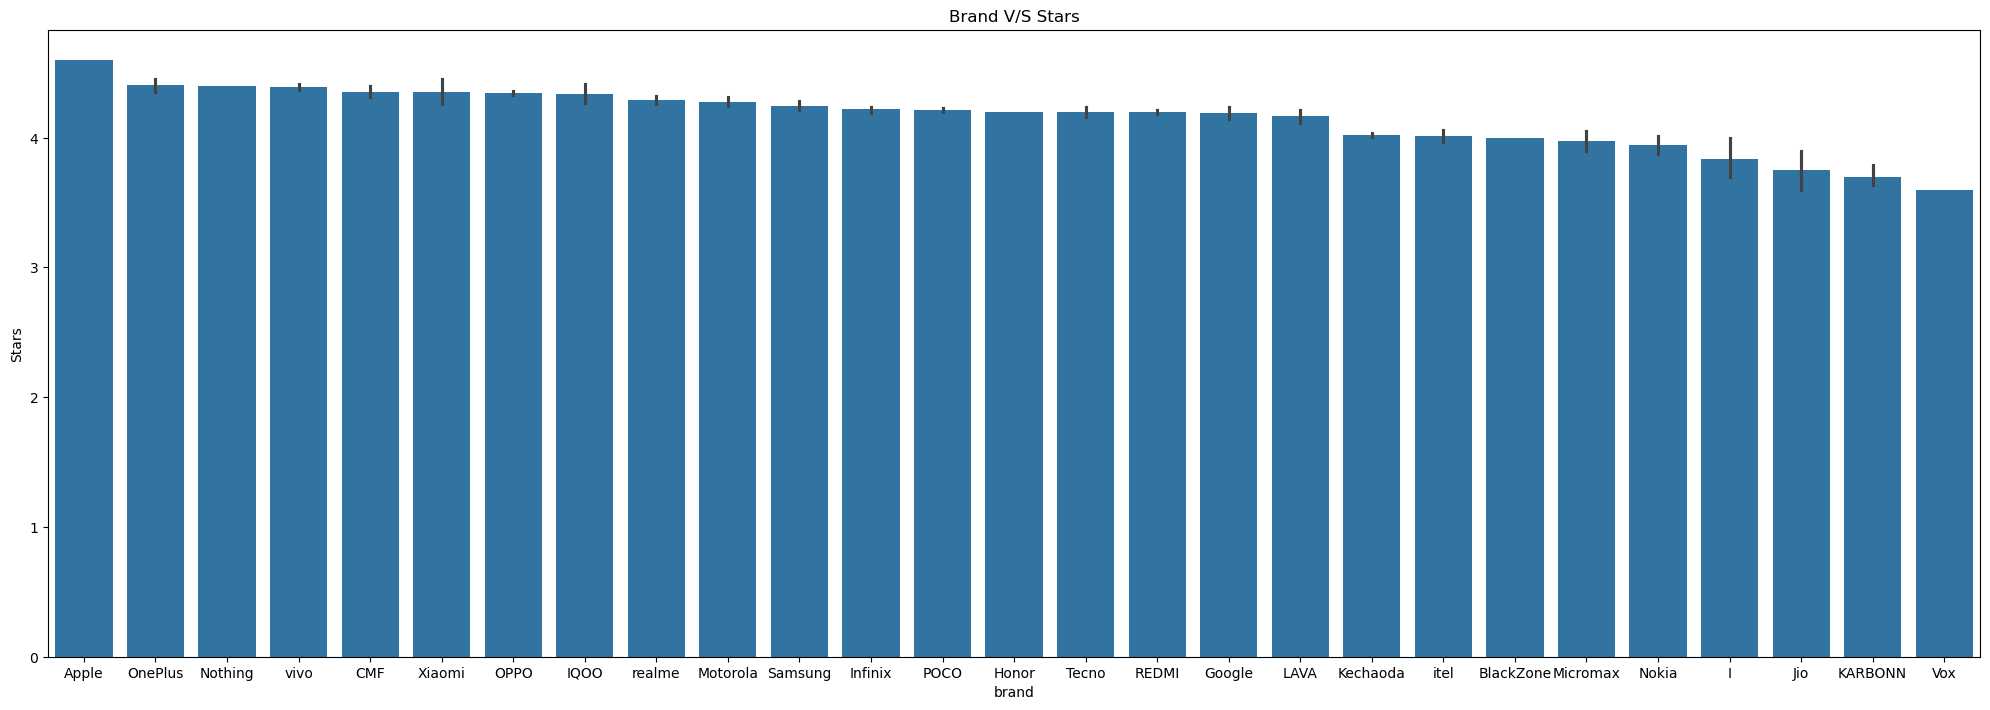

In [12]:
#Average stars by Brands
plt.figure(figsize=(20,7))
sns.barplot(
    data=clean_df,
    x="brand",
    y="Stars",
    order=clean_df.groupby("brand")["Stars"].mean().sort_values(ascending=False).index
)
plt.tight_layout()
plt.title("Brand V/S Stars")

<Axes: xlabel='Actual_price', ylabel='Discount_price'>

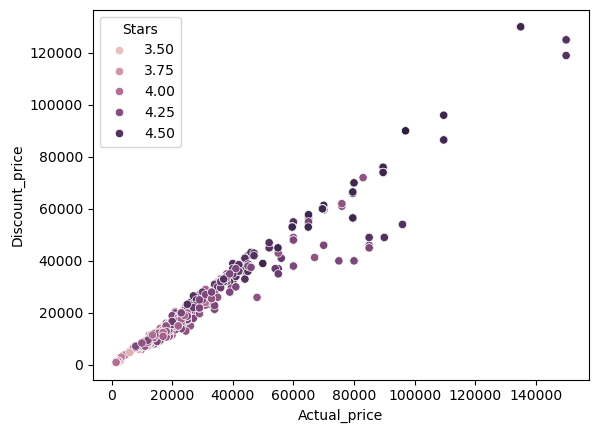

In [36]:
sns.scatterplot(
    data=clean_df,
    x="Actual_price",
    y="Discount_price",
    hue="Stars"
)

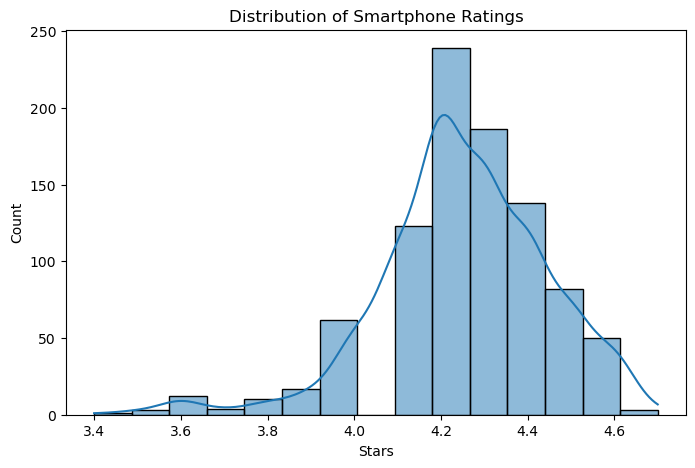

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df["Stars"], bins=15, kde=True)
plt.title("Distribution of Smartphone Ratings")
plt.xlabel("Stars")
plt.show()

In [15]:
clean_df.head()

,Product Name,Actual_price,Discount_price,Stars,Rating,Reviews,discount_percentage,brand
0,"Apple iPhone 15 (Green, 128 GB)",79600.0,65999.0,4.6,44793,2402,17.09,Apple
1,"Apple iPhone 15 (Blue, 128 GB)",79600.0,65999.0,4.6,44793,2402,17.09,Apple
2,"Apple iPhone 15 (Black, 128 GB)",79600.0,65999.0,4.6,44793,2402,17.09,Apple
3,"OnePlus N20 SE (JADE WAVE, 128 GB)",19999.0,11489.0,4.0,1005,41,42.55,OnePlus
4,"OnePlus N20 SE (BLUE OASIS, 64 GB)",16999.0,12999.0,4.0,1005,41,23.53,OnePlus


In [21]:
def generate_insights(df):
    print("\n KEY INSIGHTS:\n")

    # Top brands by rating
    top_brands = df.groupby("brand")["Stars"].mean().sort_values(ascending=False).head(3)
    print("Top 3 brands by average rating:")
    print(top_brands, "\n")

    # Budget insight
    budget = df[df["Actual_price"] < 17000]["Stars"].mean()
    premium = df[df["Actual_price"] > 30000]["Stars"].mean()
    print(f"Avg rating (Budget phones <17k): {round(budget,2)}")
    print(f"Avg rating (Premium phones >30k): {round(premium,2)}\n")

    # Discount vs rating
    corr = df["discount_percentage"].corr(df["Stars"])
    print(f"Correlation between discount and rating: {round(corr,2)}")
    if corr > 0:
        print("Higher discounts slightly improve ratings")
    else:
        print("Discounts do NOT significantly improve ratings")

generate_insights(clean_df)


 KEY INSIGHTS:

Top 3 brands by average rating:
brand
Apple      4.600000
OnePlus    4.408333
Nothing    4.400000
Name: Stars, dtype: float64 

Avg rating (Budget phones <17k): 4.13
Avg rating (Premium phones >30k): 4.38

Correlation between discount and rating: -0.27
Discounts do NOT significantly improve ratings


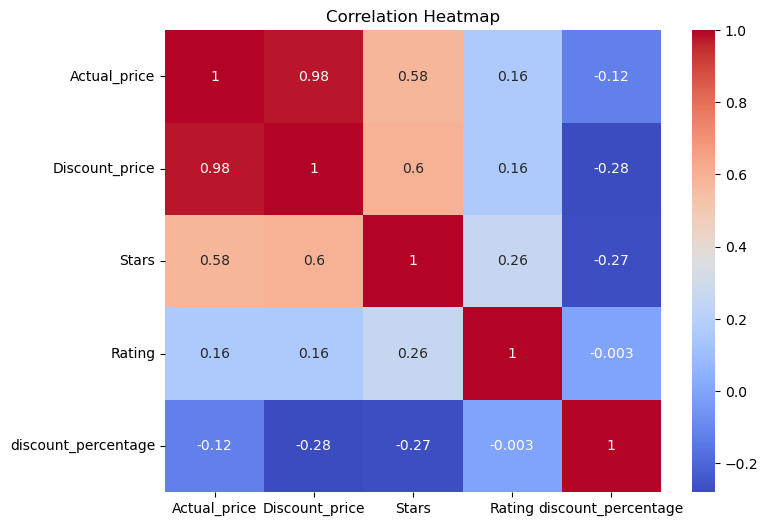

In [19]:
plt.figure(figsize=(8,6))
corr = clean_df[["Actual_price","Discount_price","Stars","Rating","discount_percentage"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()